In [26]:
!pip install statsmodels
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.formula.api import ols

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 322.1 kB/s  0:00:44eta 0:00:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [statsmodels] [statsmodels]

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip


In [28]:
import pandas as pd
df=pd.read_csv("salary_dataset.csv")

In [29]:
df.head()

,sl,YearsExperience,Salary
0,0,1.2,39344
1,1,1.4,46206
2,2,1.6,37732
3,3,2.1,43526
4,4,2.3,39892


In [17]:
df.drop('sl',axis=1)

,YearsExperience,Salary
0,1.2,39344
1,1.4,46206
2,1.6,37732
3,2.1,43526
4,2.3,39892
5,3.0,56643
6,3.1,60151
7,3.3,54446
8,3.3,64446
9,3.8,57190


In [33]:
df.describe()

,sl,YearsExperience,Salary
count,30.000000,30.000000,30.000000
mean,14.500000,5.413333,76004.000000
std,8.803408,2.837888,27414.429785
min,0.000000,1.200000,37732.000000
25%,7.250000,3.300000,56721.750000
50%,14.500000,4.800000,65238.000000
75%,21.750000,7.800000,100545.750000
max,29.000000,10.600000,122392.000000


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   sl               30 non-null     int64  
 1   YearsExperience  30 non-null     float64
 2   Salary           30 non-null     int64  
dtypes: float64(1), int64(2)
memory usage: 848.0 bytes


In [32]:
df.shape

(30, 3)

In [35]:
ols_formula="YearsExperience~Salary"
OLS=ols(formula=ols_formula,data=df)
model=OLS.fit()


In [36]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:        YearsExperience   R-squared:                       0.957
Model:                            OLS   Adj. R-squared:                  0.955
Method:                 Least Squares   F-statistic:                     622.5
Date:                Mon, 16 Feb 2026   Prob (F-statistic):           1.14e-20
Time:                        14:24:49   Log-Likelihood:                -26.168
No. Observations:                  30   AIC:                             56.34
Df Residuals:                      28   BIC:                             59.14
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -2.2833      0.327     -6.976      0.000      -2.954      -1.613
Salary         0.0001   4.06e-06     24.950      0.000     9.3e-05       0.000
==============================================================================
Omnibus:                        3.544   Durbin-Watson:                   1.587
Prob(Omnibus):                  0.170   Jarque-Bera (JB):                2.094
Skew:                          -0.412   Prob(JB):                        0.351
Kurtosis:                       2.003   Cond. No.                     2.41e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.41e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

<Axes: xlabel='YearsExperience', ylabel='Salary'>

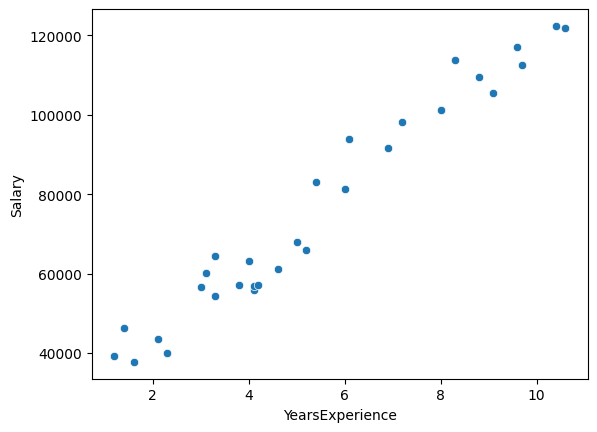

In [37]:
sns.scatterplot(x=df["YearsExperience"],y=df["Salary"])

In [38]:
prediction=model.predict()

In [39]:
print(prediction)

[ 1.70093427  2.39581922  1.53769402  2.12442725  1.75642785  3.45272891
  3.80796884  3.23024825  4.24290484  3.50812122  4.11865188  3.36685563
  3.48462759  3.49718453  3.90528514  4.59662579  4.40330965  6.13080053
  5.95611727  7.22973546  7.00674848  7.66851956  7.97525325  9.24208664
  8.79844179  8.40867027  9.56178233  9.12289696 10.11084473 10.05828786]


In [40]:
print(model.params)

Intercept   -2.283262
Salary       0.000101
dtype: float64


In [48]:
pre=pd.DataFrame({'Salary': [59990]})
print("Predicted year of experience:",model.predict(pre).iloc[0])

Predicted year of experience: 3.7916650664873264
